In [24]:
# using Pkg

# Pkg.build("PyCall")

In [1]:
# loading modules
using PyPlot, Printf, LinearAlgebra, FFTW, FileIO, JLD2

using CUDA

using Setfield

# include("../../LinStab/mjcl_stab.jl")
# using .LinStab

using FourierFlows: CPU, TwoDGrid, plan_flows_rfft

using GeophysicalFlows

using Glob

using Statistics

using Parameters

using StaticArrays, KernelAbstractions

run_file_dir = "/scratch/cimes/ml1994/QG/julia/QG_topo/"
include(run_file_dir * "mjcl_gfjl_fcns.jl")


update_two_layer_omega_diags (generic function with 2 methods)

# Defining model parameters

In [2]:

dev = GeophysicalFlows.CPU()

Ny = Nx = n = 1024                # 2D resolution = n²


###################################################################################
## Geometry and background fields
###################################################################################

Nz = nlayers = 2                 # number of layers
f0 = f₀= 8.3e-5            # Coriolis param [s^-1]
g = 9.81                    # gravity
H = [2000., 2000.]     # the rest depths of each layer;

Us = [0.01, 0.017634058790440166, 0.024]
rhos = 1025.75 - 0.5775

kt = 0.

rho0 = 1025.        # Boussinesq reference density

# always zero for now, model can't even take this in as a parameter...
V = zeros(nlayers)


# running model

rho = ρ = [0., 1025.75]
rho[1] = ρ[1] = rhos[1]

strat_str = "uni_strat"
shear_str = "uni_shear"

# change U here
U = [0.,0.]
U[1] = Us[1]

gprime = (g/rho0)*(ρ[2] - ρ[1])

Ld = sqrt(gprime * sum(H)) / 2 / f0

L = Lx = Ly = 25*2*pi*Ld   # domain size [m]

###################################################################################
## Planetary PV gradient
###################################################################################
betas = βs = collect(range(-1.5,1.5,13)) * (U[1]/2) * Ld^-2
β = 0. # 1e-11              # the y-gradient of planetary PV; beta = β = 0. * (U[1]/2) * Ld^-2

###################################################################################
## Topography
###################################################################################

# set topography w/ current options:
topo_type = "y_slope"

# Defining a bulk slope parameter...should probably change this!

# setting slope(s)
S32 = f0 * U[1] / gprime

dyetab_over_S32 = collect(range(-1.5,1.5,13))
h0s = dyetab_over_S32 .* S32
# h0s = h0s[7:end]

# tuple of (bottom slope, h_rms)
h0 = (h0s[1], 0.)    #

# central wavenumber for rough topo
kt = 0.

# defining GFJL topo params
interim_params = mod_params(topo_type=topo_type, h0=h0, kt=kt)

topographic_pv_gradient, eta = define_topo(interim_params)

###################################################################################
# Dissipation
###################################################################################

# biharmonic viscosity
nν = 4
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-13 , 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13]
nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7
ν = nus[1]

dyn_nu = true

# Linear bottom drag
μstars = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
mus = @. μstars * ((U[1]-U[end]) / 2) / Ld

# Quadratic bottom drag
κstars = [0.]
kappas = [0.] # @. κstars / Ld

###################################################################################
## Time stepping and sample rate
###################################################################################

if ν==0.
    stepper = "FilteredETDRK4"
    # af = 0.
    # global filt_order=4
    # global innerK = 2/3
else
    stepper = "ETDRK4"
    # af = 1/3
    # global filt_order=4
    # innerK = 2/3
end

# should I set dt via CFL condition instead?
dt = 600.

###################################################################################
## Details of saving data
###################################################################################
global diags = diag_bools(two_layer_kspace_modal_nrg_budget_bool=true);

# where to save model output; frequency of output
data_dir = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p5_init/"

f_s = 5. * (Ld / ((U[1]-U[end])/2)) #  N eddy turnover periods

# sampling period in time steps (set above)
nsubs = round(Int64, f_s/dt)

###################################################################################
## Model run parameters
###################################################################################

# steady-state  parameters
ss_yr_max = ceil(100 * (Ld / ((U[1]-U[end])/2)) / 3600 / 24 / 365.25)  # number of eddy periods converted to years for model run
yr_increment = 1.0 # how often to write to a save file

restart_bool = false

###################################################################################
## Define params struct
###################################################################################
global model_params = mod_params(
data_dir = data_dir,
Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
H = H,
rho0 = rho0, rho = rho, strat_str = strat_str,
shear_str = shear_str, U = U,
μ = mus[1], κ = kappas[1], nν = nν, ν = ν, dyn_nu = dyn_nu,
eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
f0=f0, β = β,
dt = dt,
stepper = stepper,
dev = dev,
restart_bool = restart_bool,
ss_yr_max = ss_yr_max,
yr_increment = yr_increment,
nsubs = nsubs)

###################################################################################
## Initialize model
###################################################################################

prob, prob_filt = initialize_model(model_params);

# prob = set_initial_conditions(prob, prob_filt, model_params)

sol, clock, params, vars, grid = prob.sol, prob.clock, prob.params, prob.vars, prob.grid;




In [3]:
dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE);


In [4]:
function redef_mu_kappa(model_params, mu, kappa)
    @unpack_mod_params model_params

    mp_out = mod_params(
    data_dir = data_dir,
    Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
    H = H,
    rho0 = rho0, rho = rho, strat_str = strat_str,
    shear_str = shear_str, U = U,
    μ = mu , κ = kappa , nν = nν, ν = ν, dyn_nu=dyn_nu,
    eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
    β = β,
    dt = dt,
    stepper = stepper,
    dev = dev,
    restart_bool = restart_bool,
    ss_yr_max = ss_yr_max,
    yr_increment = yr_increment,
    nsubs = nsubs);

    return mp_out
end

redef_mu_kappa (generic function with 1 method)

In [5]:
using PlotUtils

cm = cgrad(:coolwarm);
clrs = [cm[i] for i in range(0,1,100)]

hc_range = collect(range(h0s[1],h0s[end],100))

function h_color(h_in,hc_range,colors)
    c_ind = argmin(abs.(h_in .- (hc_range)))

    color_out = [red(clrs[c_ind]),green(clrs[c_ind]),blue(clrs[c_ind])]

    if h_in==0
        color_out = [0.,0.,0.]
    end
    return color_out
end

####################################################################
## 
####################################################################

function plot_info_box(ax, var, x, y, plus_mode, fsize)
    textstr = var * "\n" * L"+ \rightarrow" * plus_mode

    # these are matplotlib.patch.Patch properties
    props = Dict("boxstyle"=>"round", "facecolor"=>"wheat", "alpha"=>0.5)
    
    # place a text box in upper left in axes coords
    ax.text(x, y, textstr, transform=ax.transAxes, fontsize=fsize,
            ha="left", va="top", bbox=props)

    return nothing
end


####################################################################
## 
####################################################################


# tab20_range = collect(range(0,1,20))

function tab20_color(c_ind)

    cm2 = cgrad(:tab20);
    clrs2 = [cm2[i] for i in range(0,1,20)]

    color_out = [red(clrs2[c_ind]),green(clrs2[c_ind]),blue(clrs2[c_ind])]

    return color_out
end



tab20_color (generic function with 1 method)

In [6]:
readdir(data_dir)

39-element Vector{String}:
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr0.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr2.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 135 bytes ⋯ "nu4.464E+25_res1024_yr88.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr0.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr2.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 135 bytes ⋯ "nu4.464E+25_res1024_yr88.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr0.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr2.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 135 bytes ⋯ "nu4.464E+25_res1024_yr88.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr0.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 134 bytes ⋯ "_nu4.464E+25_res1024_yr2.0.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 135 bytes ⋯ "nu4.464E+25_res1024_y

In [7]:
h0s

13-element Vector{Float64}:
 -0.0002252538491070211
 -0.0001877115409225176
 -0.00015016923273801407
 -0.00011262692455351055
 -7.508461636900704e-5
 -3.754230818450352e-5
  0.0
  3.754230818450352e-5
  7.508461636900704e-5
  0.00011262692455351055
  0.00015016923273801407
  0.0001877115409225176
  0.0002252538491070211

# Load file

In [76]:
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11]
nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7
ν = nus[1]


i=4 # bottom slope index
k=2  # linear drag index

data_dir = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_init/"

h0 = (h0s[i], 0.0)
kappa_loc = 0.0
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[1])
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[1])

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)

# filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"

# added 2pi added tot
a = load(data_dir*jld_name(model_params,44.0))
# a = load(data_dir*filename)


# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_0.000E+00_beta3.116E-12_uni_shear_uni_strat_mu8.826E-08_kappa0.000E+00_nu0.000E+00_res1024_yr57.7.jld

println(data_dir*jld_name(model_params,44.0))

/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_init//layer2_H_4000.0_L_4.449E+06_y_slope_h0_-1.126E-04_beta0.000E+00_uni_shear1.000E+000.000E+001.000E+03_uni_strat1.025E+031.026E+031.000E+03__mu4.413E-08_kappa0.000E+00_nu4.464E+27_res1024_yr44.0.jld


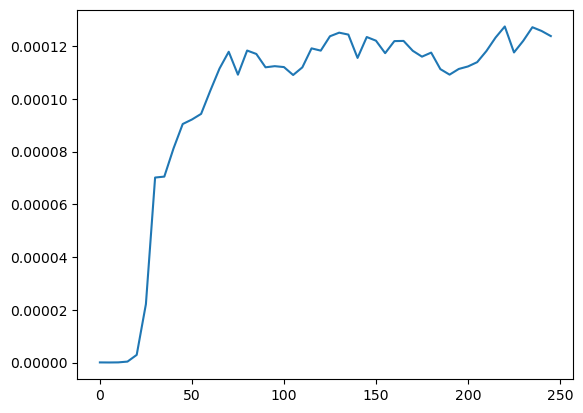

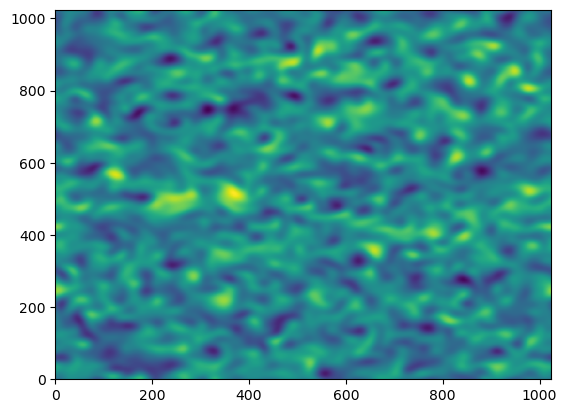

PyObject <matplotlib.collections.QuadMesh object at 0x15368cba9150>

In [77]:
t = a["jld_data"]["t"][2:end] .* (U[1]/2/Ld)

plt.plot(t, a["jld_data"]["layered_nrg_ot"][1,1:length(t)])


plt.figure()

plt.pcolormesh(a["jld_data"]["psi_yrs_end"][:,:,1]')


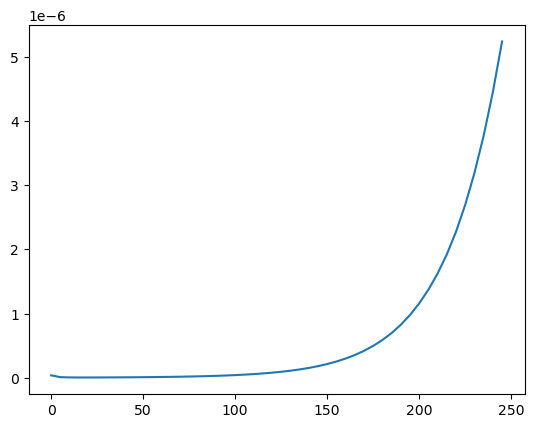

13-element Vector{Float64}:
 -0.0002252538491070211
 -0.0001877115409225176
 -0.00015016923273801407
 -0.00011262692455351055
 -7.508461636900704e-5
 -3.754230818450352e-5
  0.0
  3.754230818450352e-5
  7.508461636900704e-5
  0.00011262692455351055
  0.00015016923273801407
  0.0001877115409225176
  0.0002252538491070211

In [43]:
t = a["jld_data"]["t"][2:end] .* (U[1]/2/Ld)

plt.plot(t, a["jld_data"]["layered_nrg_ot"][1,1:length(t)])


h0s

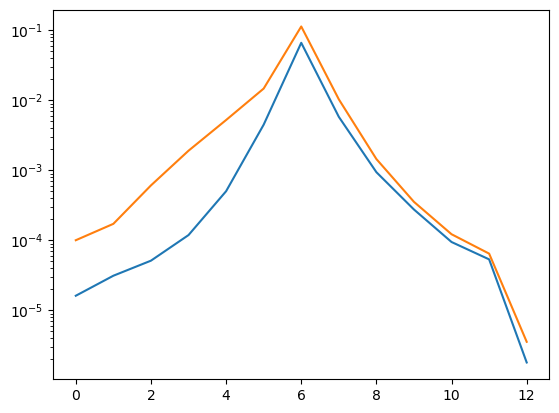

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x15368d25c520>

In [57]:
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11]
# νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13]
nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7

EKE_of_h_hinu = zeros(13)

for i in range(1,13) # bottom slope index
    k=2  # linear drag index
    
    h0 = (h0s[i], 0.0)
    kappa_loc = 0.0
    mu_loc = mus[k]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
    
    # global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)
    
    # filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"
    
    # added 2pi added tot
    a = load(data_dir*jld_name(model_params, 44.0))
    t = a["jld_data"]["t"][2:end] .* (U[1]/2/Ld)

    EKE_of_h_hinu[i] = mean(a["jld_data"]["layered_nrg_ot"][1,round(Int, 2*length(t)/3):length(t)])
end

plt.semilogy(EKE_of_h_hinu)
plt.semilogy(EKE_of_h)


# /scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_init//layer2_H_4000.0_L_4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear1.000E+000.000E+001.000E+03_uni_strat1.025E+031.026E+031.000E+03__mu4.413E-08_kappa0.000E+00_nu4.464E+27_res1024_yr44.0.jld

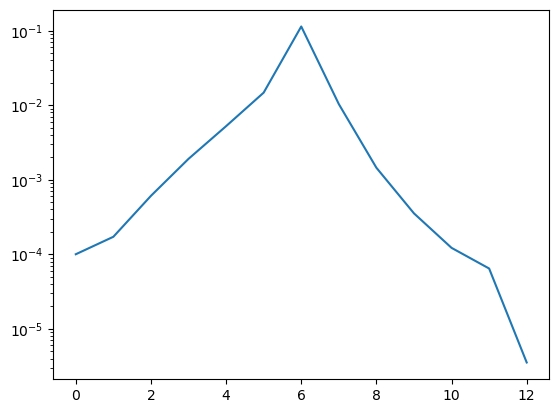

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x15368d352f50>

In [56]:
# νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11]
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13]
νstars = [10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13 , 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13]

nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7


EKE_of_h = zeros(13)

for i in range(1,13) # bottom slope index
    k=2  # linear drag index
    
    
    h0 = (h0s[i], 0.0)
    kappa_loc = 0.0
    mu_loc = mus[k]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
    
    # global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)
    
    # filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"
    
    # added 2pi added tot
    a = load(data_dir*jld_name(model_params, 44.0))

    t = a["jld_data"]["t"][2:end] .* (U[1]/2/Ld)

    EKE_of_h[i] = mean(a["jld_data"]["layered_nrg_ot"][1,round(Int, 2*length(t)/3):length(t)])
end

plt.semilogy(EKE_of_h)

    
    

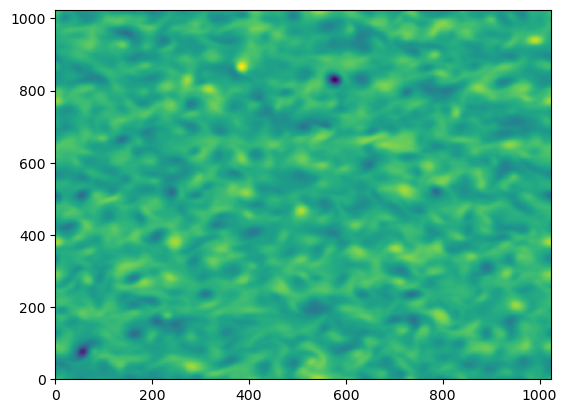

PyObject <matplotlib.collections.QuadMesh object at 0x15368cf69d80>

In [67]:

plt.pcolormesh(a["jld_data"]["psi_yrs_end"][:,:,1]')


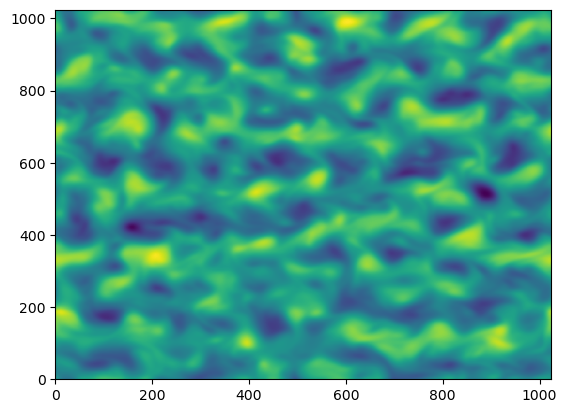

PyObject <matplotlib.collections.QuadMesh object at 0x150aa80ddc60>

In [17]:

plt.pcolormesh(a["jld_data"]["psi_yrs_end"][:,:,1]')



In [144]:
ψ = a["jld_data"]["psi_yrs_end"]

nlayers = Nz

dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplanlayered = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, nlayers), [1, 2]; flags=FFTW.MEASURE)
rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE)

# parameters
gr = gp(rho[1:2],rho0,g) 

Ld = sqrt(gr * sum(H)) / (2 * f0)
# ∂yηb = topographic_pv_gradient[2] / (f0 / H[end])

ψh = deepcopy(vars.ψh)

mul!(ψh, rfftplanlayered, deepcopy(ψ))

u = deepcopy(ψ)
v = deepcopy(ψ)

ldiv!(u, rfftplanlayered, -im * grid.l  .* ψh)
ldiv!(v, rfftplanlayered, im * grid.kr  .* ψh);

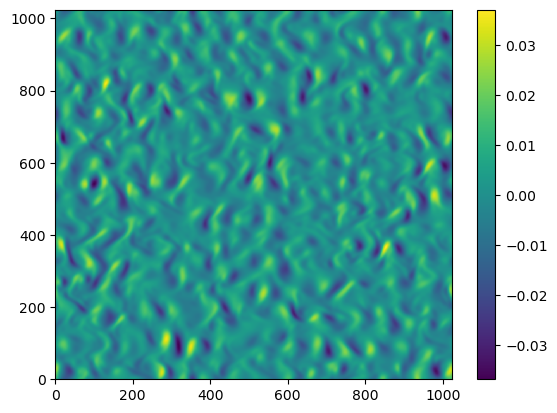

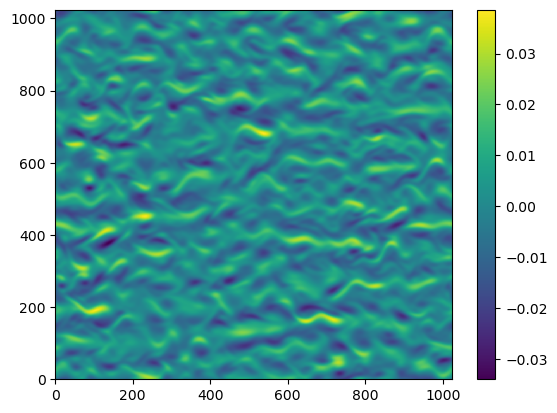

PyObject <matplotlib.colorbar.Colorbar object at 0x1530806375e0>

In [145]:
plt.pcolormesh((v[:,:,1]  .- mean(v[:,:,1], dims=1))')

plt.colorbar()

plt.figure()

plt.pcolormesh((u[:,:,1]  .- mean(u[:,:,1], dims=1))')

plt.colorbar()

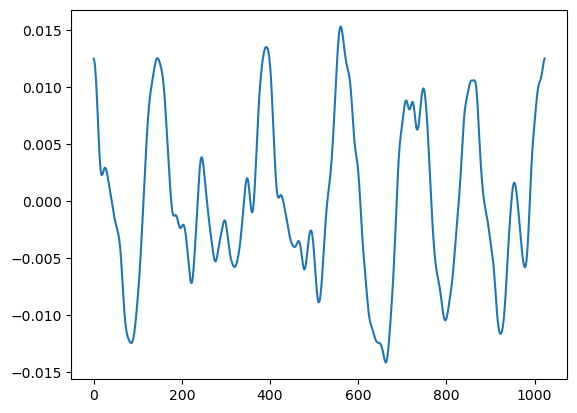

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x153080a63ee0>

In [139]:
plt.plot( mean(u[:,:,1], dims=1)')

# Steady-state stuff

In [58]:
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11]
nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7
ν = nus[1]


i=6 # bottom slope index
k=2  # linear drag index

data_dir = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_SS/"

h0 = (h0s[i], 0.0)
kappa_loc = 0.0
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)

# filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"

# added 2pi added tot
a = load(data_dir*jld_name(model_params,88.0))
# a = load(data_dir*filename)


# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_0.000E+00_beta3.116E-12_uni_shear_uni_strat_mu8.826E-08_kappa0.000E+00_nu0.000E+00_res1024_yr57.7.jld



Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>NaN, "t"=>[1.38853e9, 1.38854e9,…

In [89]:
println(a["jld_data"]["two_layer_xspace_modal_nrg_budget"][end,1])

a["jld_data"]["two_layer_xspace_modal_nrg_budget"][6,1]


# budget is nrgs_in_x .+ A(vcat(BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

5.984905805819839e-11


2.1973442217882268e-10

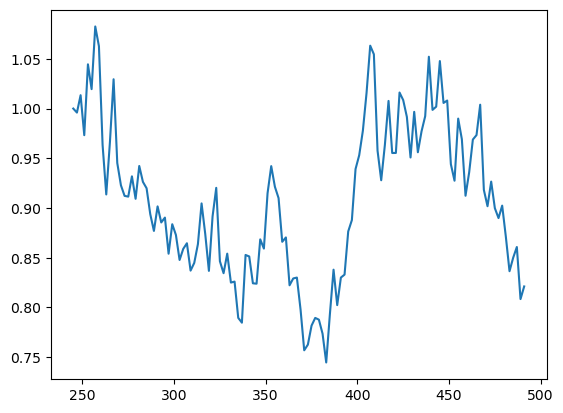

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14dd5e0188b0>

In [90]:

t = a["jld_data"]["t"][2:end] .* (U[1]/2/Ld)

plt.plot(t, a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1:length(t)] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1])


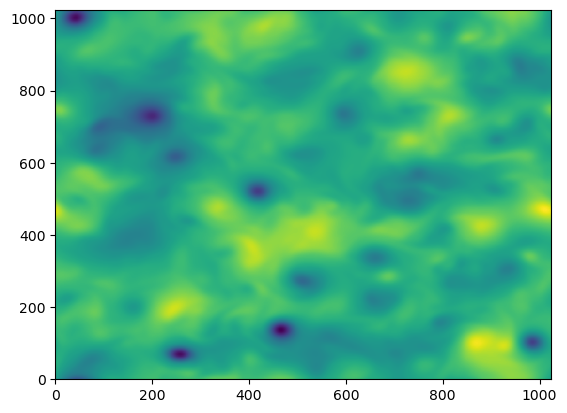

PyObject <matplotlib.collections.QuadMesh object at 0x14dd5e05c8b0>

In [91]:

plt.pcolormesh(a["jld_data"]["psi_yrs_end"][:,:,1]')



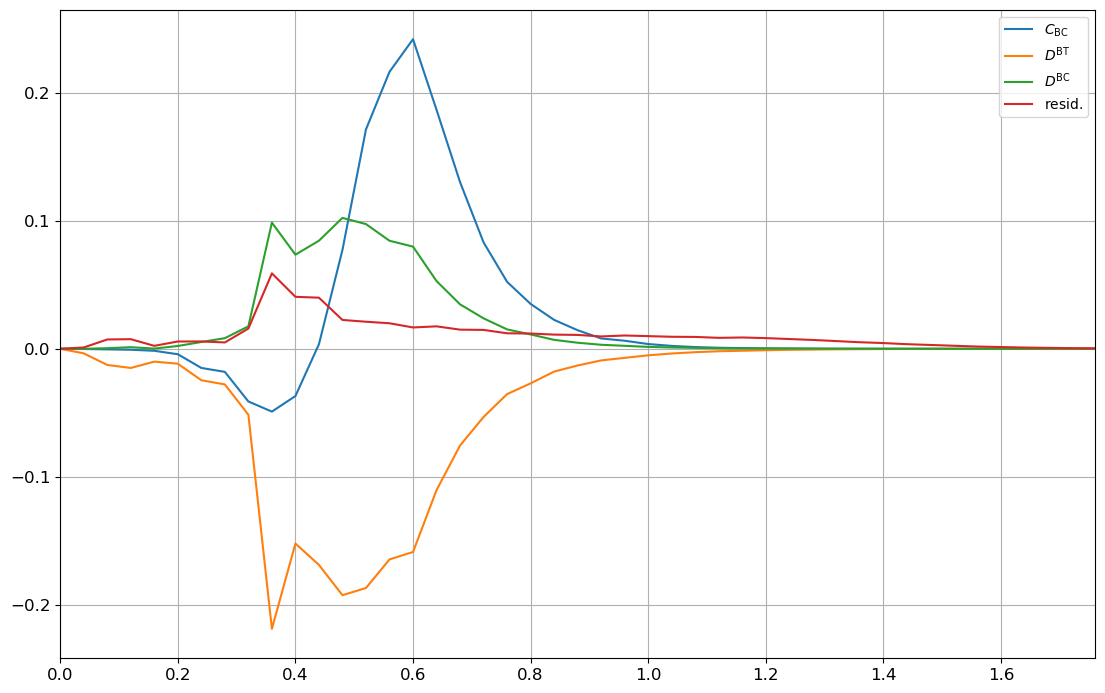

PyObject <matplotlib.legend.Legend object at 0x14def9d4e320>

In [82]:
# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(1,1,figsize=(10.5, 6.5))
fig.tight_layout(pad=-1.0)



h_ind = i = 13 # bottom slope index
k=2  # linear drag index

data_dir = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_SS/"

h0 = (h0s[i], 0.0)
kappa_loc = 0.0
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)

# filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"

# added 2pi added tot
a = load(data_dir*jld_name(model_params,88.0))
# a = load(data_dir*filename)



# h_ind=17
xmax_ind = 45
x = grid.kr .* Ld

fsize = 20
bsize = 16
lsize = 12

if h_ind<7
    lt = "dashed"
elseif h_ind>=7
    lt="solid"
end
    
norm = (sqrt(2*a["jld_data"]["two_layer_xspace_modal_nrg_budget"][1]))^-3 / Ld

# k-space energies are, BTEKE, BCEKE, EAPE; CBC; Tflat, Ttopo; , DBT, DBC; NLBT2BC, NLBTEKE; NLBC2BT, NLBCEKE, NLBCEAPE resid
 # k-space energies are, BTEKE, BCEKE, EAPE; CBC; Tflat, Ttopo; , DBT, DBC; NLBTEKE, NLBT2BC; NLBC2BT, NLBCEKE, NLBCEAPE resid

ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}" ,linestyle=lt)

# ax.plot(x, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=L"T_\mathrm{flat}",linestyle=lt)

# ax.plot(x, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=L"T_\mathrm{topo}", linestyle=lt)

ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* norm, label=L"D^\mathrm{BT}", linestyle=lt)

ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm, label=L"D^\mathrm{BC}", linestyle=lt)

# ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=L"N^{\mathrm{BT} \rightarrow \mathrm{BC}}", linestyle=lt)


# ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=L"N_\mathrm{PE}", linestyle=lt)

# ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=L"N^\mathrm{BC}_\mathrm{KE}", linestyle=lt)

ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm, label=L"\mathrm{resid.}", linestyle=lt)

ymin = -2
ymax = ymin .+ 4

# ymins = [-0.025, -0.025, -0.15]
# ymaxes = ymins .+ 0.2


ax.grid()
ax.tick_params(labelsize=lsize)
ax.set_xlim(x[1], x[xmax_ind])

# ax.set_ylim(ymin, ymax)

ax.legend()

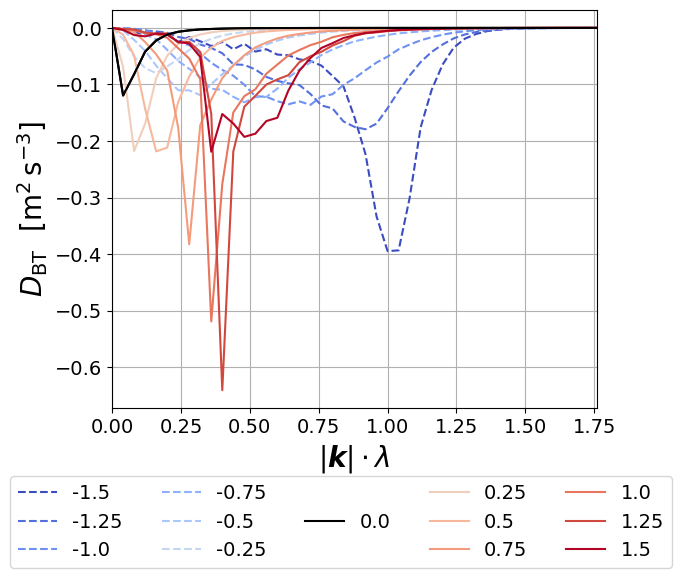

(0.0, 1.76)

In [69]:

# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(1,1,figsize=(5, 4))
fig.tight_layout(pad=-1.0)

# h_ind=17
xmax_ind = 45
x = grid.kr .* Ld

fsize = 20
bsize = 16
lsize = 14


####################################################################

####################################################################

for h_ind in vcat(collect(range(1,6)), 7, collect(range(8,13))) # length(h0s))
    if h_ind<7
        lt = "dashed"
    elseif h_ind>=7
        lt="solid"
    end

    h0 = (h0s[h_ind], 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[2]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[h_ind])
    global topo_PV, eta = define_topo(model_params)

    # # for kappa* = 1.0
    # mu_loc = mus[4]
    # global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,88.0))
    norm = (sqrt(2*a["jld_data"]["two_layer_xspace_modal_nrg_budget"][1]))^-3 / Ld

    ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)

    if h_ind==6
        ax.plot(NaN, NaN, "-", color="none", label=L" \ ")
    elseif h_ind==7
        ax.plot(NaN, NaN, "-", color="none", label=L" \ ")
    end


    GC.gc()
end


### plot again, but with no legend entry
h_ind = 7
if h_ind<7
    lt = "dashed"
elseif h_ind>=7
    lt="solid"
end

h0 = (h0s[h_ind], 0.0)
kappa_loc = kappas[1]

# for kappa* = 1.0
mu_loc = mus[2]
global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[h_ind])
    
a = load(data_dir*jld_name(model_params,88.0))
norm = (sqrt(2*a["jld_data"]["two_layer_xspace_modal_nrg_budget"][1]))^-3 / Ld

ax.plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* norm, color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)


####################################################################################
# ax[1].set_xticklabels([])
# ax[2].set_xticklabels([])
# ax[4].set_xticklabels([])
# ax[5].set_xticklabels([])
# ax[7].set_xticklabels([])
# ax[8].set_xticklabels([])

# ax[4].set_yticklabels([])
# ax[5].set_yticklabels([])
# ax[6].set_yticklabels([])
# ax[7].set_yticklabels([])
# ax[8].set_yticklabels([])
# ax[9].set_yticklabels([])

ax.legend(fontsize=lsize, loc="lower right", bbox_to_anchor=(1.175,-0.425), ncol=5)

ax.set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)
ax.set_ylabel(L"D_\mathrm{BT} \ \ \mathrm{[ m}^{2}\mathrm{ \, s}^{-3} \mathrm{]}", fontsize=fsize)
# ymins = [-0.025, -0.025, -0.15]
# ymaxes = ymins .+ 0.2

ax.grid()
ax.tick_params(labelsize=lsize)
ax.set_xlim(x[1], x[xmax_ind])


# ax.set_ylim(-0.25, 0.05)


# savefig("./drag_figs/DBT.pdf",bbox_inches="tight", transparent=true)



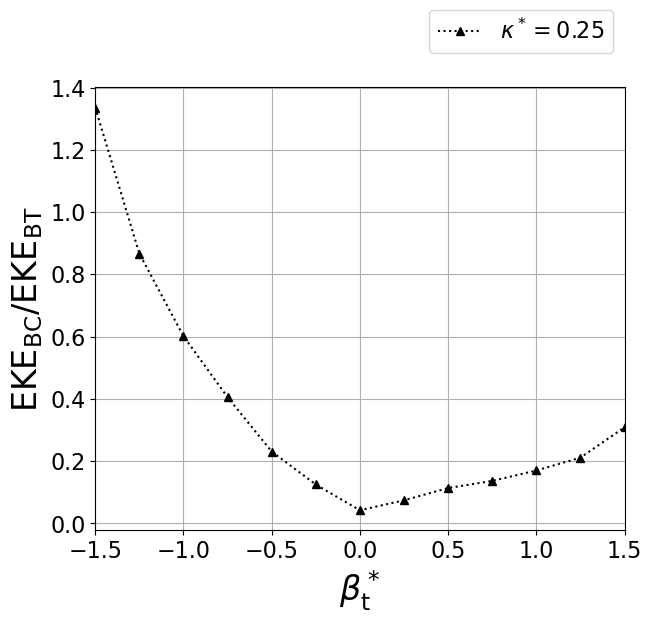

PyObject <matplotlib.legend.Legend object at 0x14def9a7fd60>

In [83]:
# fig, ax = plt.subplots(3,1, figsize=(6,13.5))
fig, ax1 = plt.subplots(1,1, figsize=(6,5))

fig.tight_layout(pad=1.0)


lsize = 24
tsize = 16

x = h0s ./ S32
x2 = x[7:end]


# BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

function define_modal_nrg_ratios(mu_loc)
        
    if mu_loc > mus[1]
        h0_range = range(1, length(h0s))

        EKEBC_over_EKEBT = zeros(length(h0s)) .* NaN
        
    else
        h0_range = range(7, length(h0s))

        EKEBC_over_EKEBT = zeros(length(h0s[7:end])) .* NaN
        
    end
    
    for (i, h_ind) in enumerate(h0_range)
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
            
        a = load(data_dir*jld_name(model_params,88.0))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)
    
        EKEBC_over_EKEBT[i] = xmn[2] / xmn[1]          # 

         # EKEBC_over_EKEBT[i] = mean(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][2:end,2] ./ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][2:end,1]) 
        
    end
        
    return EKEBC_over_EKEBT
end

# EKEBC_over_EKEBT_mu0 = define_modal_nrg_ratios(mus[1])

EKEBC_over_EKEBT_mu1 = define_modal_nrg_ratios(mus[2])

# EKEBC_over_EKEBT_mu2 = define_modal_nrg_ratios(mus[3])

# EKEBC_over_EKEBT_mu3 = define_modal_nrg_ratios(mus[4])

# EKEBC_over_EKEBT_mu4 = define_modal_nrg_ratios(mus[5])

# EKEBC_over_EKEBT_mu5 = define_modal_nrg_ratios(mus[6])


############################################################################
# ax1.plot(x2[1:end-2], EKEBC_over_EKEBT_mu0[1:end-2], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax1.plot(x, EKEBC_over_EKEBT_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x[5:end], EKEBC_over_EKEBT_mu2[5:end], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax1.plot(x, EKEBC_over_EKEBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax1.plot(x, EKEBC_over_EKEBT_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
# ax1.plot(x, EKEBC_over_EKEBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax1.plot(x, BCEKE_nu0_mu1 ./ BTEKE_nu0_mu1, color="r", marker="x", linestyle="--", label=L"\mu^* = 1.0")

ax1.set_ylabel(L" \mathrm{EKE}_\mathrm{BC} /  \mathrm{EKE}_\mathrm{BT} ", fontsize=lsize)

ax1.set_xlabel(L"\beta^*_\mathrm{t}", fontsize=lsize)

ax1.set_xlim(x[1], x[end])
# ax1.set_ylim(ax1.get_ylim()[1], 1.3)  # minimum(BCEKE_nu0_kap0p25 ./ BTEKE_nu0_kap0p25), 1.3) # 
# ax1.set_ylim(0.0, 1.1)

# ax1.set_xticklabels([])
# ax1.set_yscale("log")

ax1.tick_params(labelsize=tsize, which="both")

# ax1.legend(fontsize=tsize)

ax1.grid()

ax1.legend(fontsize=tsize, ncol=2, loc="upper right", bbox_to_anchor=(1.0, 1.2))

############################################################################
# # ax2.plot(x2, BTEKE_nu0_kap0p125, color="k", marker="^", linestyle="--", label=L"\kappa^* = 0.125")
# ax2.plot(x, BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax2.plot(x, BTEKE_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, BTEKE_nu0_kap2, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
# ax2.plot(x, BTEKE_nu0_kap4, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax2.set_ylabel(L"\langle \mathrm{EKE}_{BT} \rangle \ \ [ \mathrm{m}^2 \mathrm{s}^{-2} ]", fontsize=lsize)
# # ax2.set_xticklabels([])


# ax2.set_xlim(x[1], x[end])

# ax2.set_yscale("log")

# ax2.tick_params(labelsize=tsize, which="both")
# ax2.grid()


# ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

############################################################################

# ax2.plot(x2[1:end-2], DC_ratio_kap0p125[1:end-2], color="k", marker=".", linestyle="-.",      label=L"\kappa^* = 0.125")
# ax2.plot(x[6:end-1], DC_ratio_kap0p25[6:end-1],   color="k", marker="^", linestyle="dotted",     label=L"\kappa^* = 0.25")
# ax2.plot(x[5:end], DC_ratio_kap0p5[5:end], color="k", marker="d", linestyle="-",      label=L"\kappa^* = 0.5")
# ax2.plot(x, DC_ratio_kap1,   color="k", marker="s", linestyle="--",     label=L"\kappa^* = 1.0")
# ax2.plot(x, DC_ratio_kap2,   color="k", marker="o", linestyle="-.",     label=L"\kappa^* = 2.0")
# ax2.plot(x, DC_ratio_kap4,   color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax2.set_xlim(x[1], x[end])
# ax2.grid()

# ax2.legend(fontsize=tsize, ncol=2)

# ax2.set_ylabel(L"\int \mathrm{NL}_\mathrm{BC}^\mathrm{EKE} \ \mathrm{d} | \boldsymbol{k} | \, / \, \int  \mathrm{NL}_\mathrm{BT} \ \mathrm{d} | \boldsymbol{k} |",fontsize=lsize)
# ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2} ",fontsize=lsize)
# # ax2.set_xticklabels([])

# ax2.tick_params(labelsize=tsize, which="both")

# ax2.set_ylim(0., 5)


############################################################################
############################################################################


############################################################################
############################################################################

# ax1.text(0.05, 0.95, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.05, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);

# savefig("./drag_figs/modal_nrg_ratio.pdf",bbox_inches="tight")
